In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
tf.__version__

'2.21.0'

In [34]:
img_height , img_width = 100, 100
batch_size = 20
train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


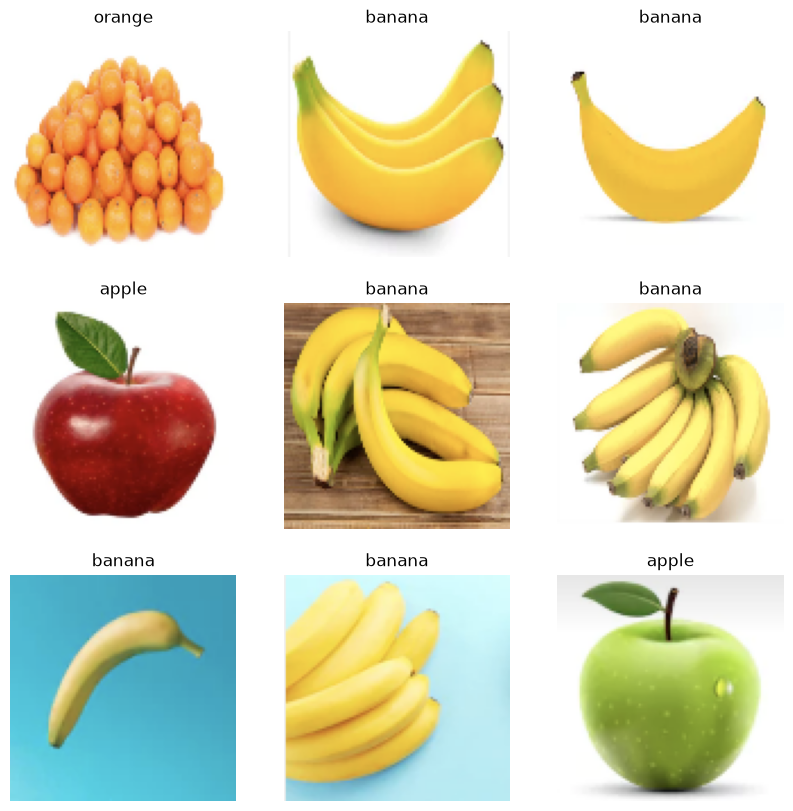

In [35]:
class_names = ["apple","banana","orange"]
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [36]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names))  # logits, no activation
])

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # back to default now that BatchNorm stabilizes things
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [42]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.9152 - loss: 0.8810 - val_accuracy: 0.4848 - val_loss: 0.9297 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9348 - loss: 0.7930 - val_accuracy: 0.3636 - val_loss: 1.7596 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9543 - loss: 0.6556 - val_accuracy: 0.5000 - val_loss: 2.7144 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9630 - loss: 0.3591 - val_accuracy: 0.3333 - val_loss: 5.8872 - learning_rate: 5.0000e-04
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9804 - loss: 0.2157 - val_accuracy: 0.3333 - val_loss: 9.8355 - learning_rate: 5.0000e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9870 - loss: 0.0592 - val_accuracy: 0.4242 - val_loss: 3.2959 - learning_rate: 2.5000e-04
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9957 - loss: 0.01

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


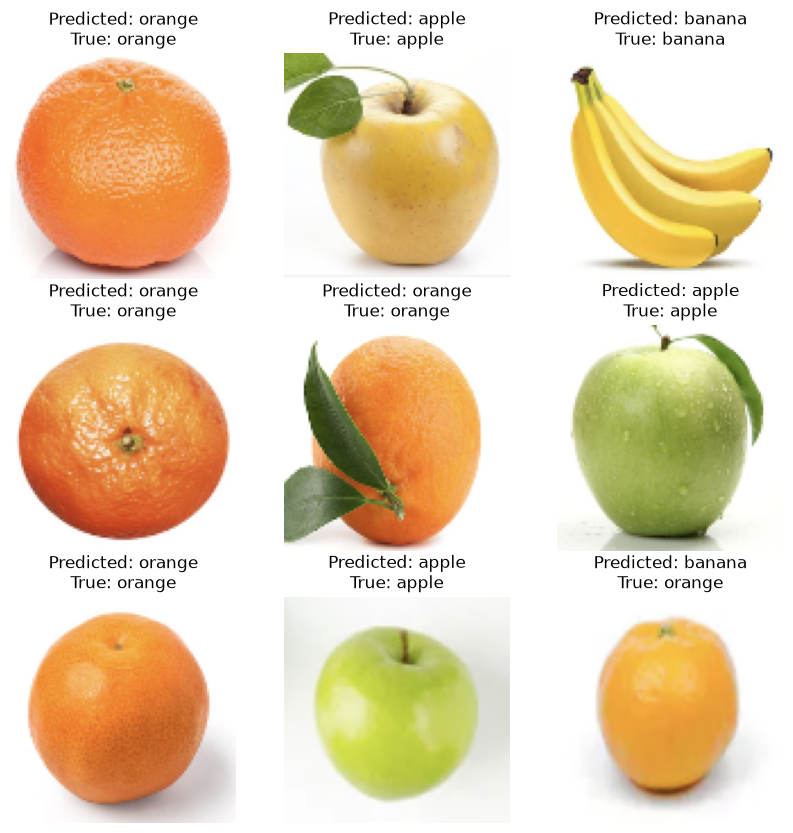

In [44]:
import numpy as np
plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_label = class_names[np.argmax(predictions[i])]
        true_label = class_names[labels[i]]
        plt.title(f"Predicted: {predicted_label}\nTrue: {true_label}")
        plt.axis("off")

In [45]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model.tflite","wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd/assets


INFO:tensorflow:Assets written to: /var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd/assets


Saved artifact at '/var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  6350562576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896065616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896063504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896066000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6350561808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896065808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896066192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896065232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896067152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12896067344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128960638

W0000 00:00:1787769729.186811 28355088 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1787769729.186824 28355088 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1787769729.187096 28355088 reader.cc:83] Reading SavedModel from: /var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd
I0000 00:00:1787769729.187906 28355088 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1787769729.187909 28355088 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd
I0000 00:00:1787769729.194808 28355088 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1787769729.195990 28355088 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1787769729.244172 28355088 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/4f/_0vf3wms19z9pqkvt29tb1280000gn/T/tmpvzavgtvd
I0000 00:00:1787769729.257669 28